# moodcompiler — Wearable Physiological Signal EDA & Model Training
### *"Behind Every Signal, There's a Story."*

**Academic B.Tech IT Research Project**  
**Institution:** Pimpri Chinchwad College of Engineering (PCCoE), Pune  
**Team:** Kanak Kushwaha, Sahil Tiwari, Aayush Kate  
**Project Guide:** Dr. Roshani Raut  

---
## 1. Overview & Research Objective
This notebook documents the exploratory data analysis, biosignal feature engineering, participant-aware validation, and classifier training on the **Wearable Depression Dataset** (11,700 samples across longitudinal wearable telemetry).

Key physiological modalities:
- **Autonomic Nervous System (ANS):** Electrodermal Activity (EDA), Heart Rate Variability (HRV)
- **Cardiovascular & Respiratory:** Heart Rate (BPM), Respiration Rate
- **Circadian & Behavioral:** Sleep Duration, Sleep Efficiency, Sedentary Hours, Step Count

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Styling for clean research figures
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

DATA_PATH = os.path.join('..', 'data', 'wearable', 'Wearable_Art_Therapy_Depression_Dataset.csv')
df = pd.read_csv(DATA_PATH)
print(f"Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head(3)

Dataset Shape: 11,700 rows, 38 columns


,Participant_ID,Age,Gender,Wearable_Device_Type,Monitoring_Duration_Days,Heart_Rate_BPM,HRV_ms,EDA_Level_uS,Skin_Temperature_C,Respiration_Rate_BPM,...,Tactile_Vibration_Level,Textile_Color_Response,Intervention_Duration_Minutes,Intervention_Frequency_Per_Week,User_Engagement_Percentage,HDRS_Baseline_Score,HDRS_Post_Intervention_Score,Symptom_Reduction_Percentage,Depression_Severity_Level,Intervention_Response
0,WAT_00001,56,Female,Wrist Wearable,52,87.42,31.63,2.92,33.84,15.11,...,Strong,Soft White,29.21,6,59.94,1.30,0.00,100.00,Normal,High Response
1,WAT_00002,46,Female,Smart Textile Band,38,89.18,37.01,4.58,33.90,15.66,...,NaN,Green Balance,13.26,7,74.71,12.93,1.63,87.39,Mild Depression,High Response
2,WAT_00003,32,Female,Sensor Patch,23,74.27,37.11,5.15,35.15,17.12,...,NaN,Purple Relax,42.48,2,67.08,7.93,0.37,95.33,Mild Depression,High Response


## 2. Target Variable Mapping (Standardizing 4 Clinical Severity Tiers)
The dataset records 5 categories. To maintain consistency across multimodal branches, **Very Severe** is grouped into **Severe Depression**, yielding 4 balanced ordinal severity tiers.

C:\Users\Kanak\AppData\Local\Temp\ipykernel_10360\3974651122.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Severity', order=order, palette=palette)


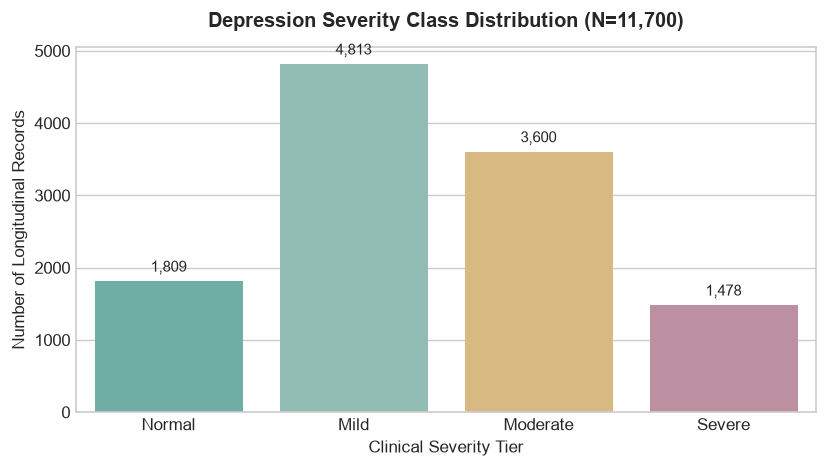

In [2]:
label_map = {
    'Normal':                 'Normal',
    'Mild Depression':        'Mild',
    'Moderate Depression':    'Moderate',
    'Severe Depression':      'Severe',
    'Very Severe Depression': 'Severe'
}
df['Severity'] = df['Depression_Severity_Level'].map(label_map)

plt.figure(figsize=(7, 4))
order = ['Normal', 'Mild', 'Moderate', 'Severe']
palette = {'Normal': '#64b8ad', 'Mild': '#8bc4b8', 'Moderate': '#e5bd73', 'Severe': '#c488a0'}
ax = sns.countplot(data=df, x='Severity', order=order, palette=palette)
plt.title('Depression Severity Class Distribution (N=11,700)', fontweight='bold', pad=12)
plt.xlabel('Clinical Severity Tier')
plt.ylabel('Number of Longitudinal Records')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Exploratory Data Analysis: Biosignal Manifestations of Depression
Clinical literature indicates:
1. **Heart Rate Variability (HRV):** Blunted parasympathetic control correlates with increased depression severity.
2. **Electrodermal Activity (EDA):** Sympathetic arousal surges during acute somatic stress.

C:\Users\Kanak\AppData\Local\Temp\ipykernel_10360\2675770283.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Severity', y='HRV_ms', order=order, palette=palette, ax=axes[0])
C:\Users\Kanak\AppData\Local\Temp\ipykernel_10360\2675770283.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Severity', y='EDA_Level_uS', order=order, palette=palette, ax=axes[1])


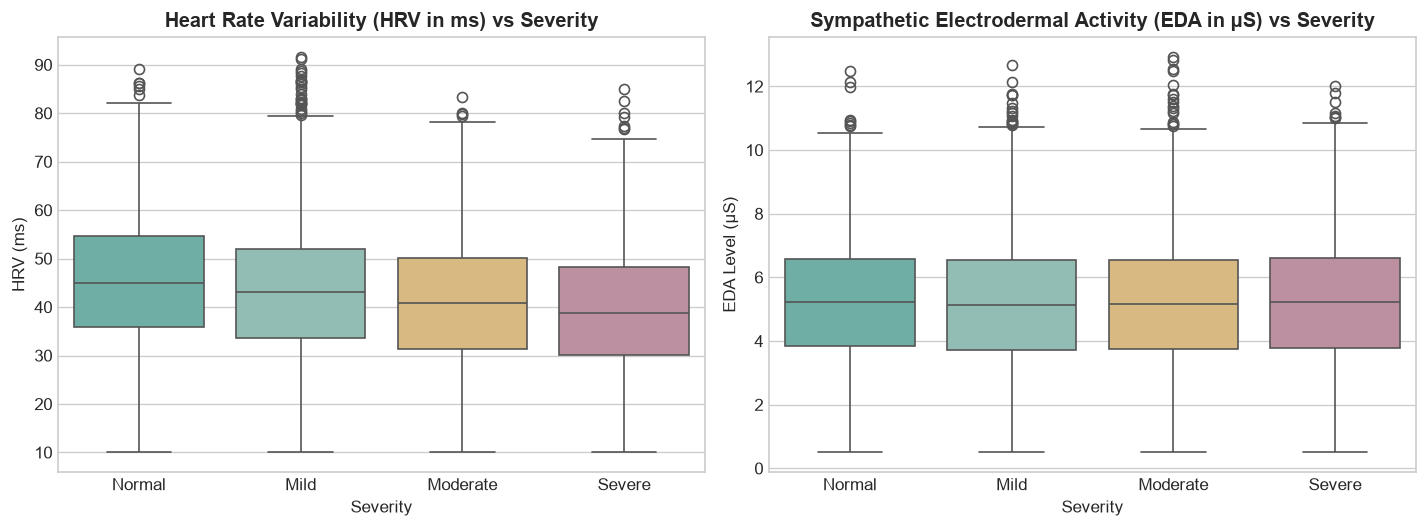

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# HRV across severity
sns.boxplot(data=df, x='Severity', y='HRV_ms', order=order, palette=palette, ax=axes[0])
axes[0].set_title('Heart Rate Variability (HRV in ms) vs Severity', fontweight='bold')
axes[0].set_ylabel('HRV (ms)')

# EDA across severity
sns.boxplot(data=df, x='Severity', y='EDA_Level_uS', order=order, palette=palette, ax=axes[1])
axes[1].set_title('Sympathetic Electrodermal Activity (EDA in µS) vs Severity', fontweight='bold')
axes[1].set_ylabel('EDA Level (µS)')

plt.tight_layout()
plt.show()

## 4. Feature Engineering: Non-Linear Biosignal Ratios
We construct physiologically grounded interaction terms:
- **Cardiac Stress Index:** $\text{HR} / \text{HRV}$
- **Autonomic Load Index:** $(\text{EDA} \times \text{HR}) / \text{HRV}$
- **Circadian Rest Ratio:** $\text{Sedentary Hours} / \text{Sleep Duration}$

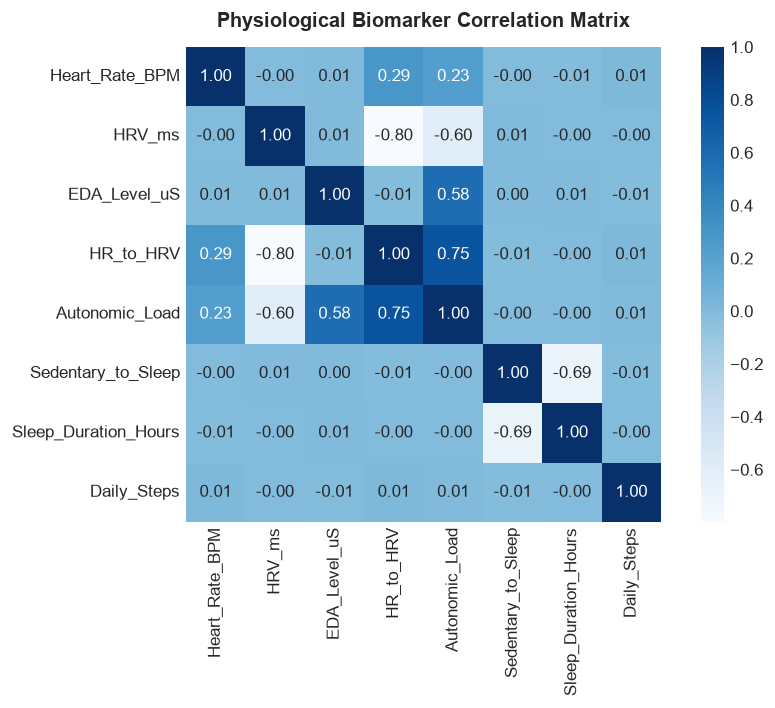

In [4]:
df['HR_to_HRV'] = df['Heart_Rate_BPM'] / (df['HRV_ms'] + 1e-4)
df['Autonomic_Load'] = (df['EDA_Level_uS'] * df['Heart_Rate_BPM']) / (df['HRV_ms'] + 1e-4)
df['Sedentary_to_Sleep'] = df['Sedentary_Time_Hours'] / (df['Sleep_Duration_Hours'] + 1e-4)

features_to_plot = ['Heart_Rate_BPM', 'HRV_ms', 'EDA_Level_uS', 'HR_to_HRV', 'Autonomic_Load', 'Sedentary_to_Sleep', 'Sleep_Duration_Hours', 'Daily_Steps']
plt.figure(figsize=(8, 6))
corr = df[features_to_plot].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', cbar=True, square=True)
plt.title('Physiological Biomarker Correlation Matrix', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 5. Participant-Aware Validation Split (No Data Leakage)
Because longitudinal observations exist per participant, a standard random row split would leak participant traits into the test set. We enforce a **GroupShuffleSplit** based on `Participant_ID`.

In [5]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder

FEATURES = [
    'Heart_Rate_BPM', 'HRV_ms', 'EDA_Level_uS', 'Skin_Temperature_C', 'Respiration_Rate_BPM',
    'HR_to_HRV', 'Autonomic_Load', 'Sleep_Duration_Hours', 'Daily_Steps', 'Sedentary_Time_Hours',
    'Sedentary_to_Sleep', 'Mood_Score', 'Stress_Index', 'Anxiety_Index', 'Age'
]

X = df[FEATURES].fillna(df[FEATURES].median())
le = LabelEncoder()
le.fit(order)
y = le.transform(df['Severity'])
groups = df['Participant_ID']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Unique Participants - Train: {groups.iloc[train_idx].nunique()}, Test: {groups.iloc[test_idx].nunique()}")
print(f"Samples - Train: {len(X_train):,}, Test: {len(X_test):,}")

Unique Participants - Train: 9360, Test: 2340
Samples - Train: 9,360, Test: 2,340


## 6. Model Training & Comparative Evaluation
We train multiple classifier architectures:
1. **Logistic Regression (Linear Baseline)**
2. **Random Forest (Ensemble Bagging)**
3. **XGBoost (Gradient Boosted Decision Trees)**

In [6]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

models = {
    'Logistic Regression': LogisticRegression(max_iter=1500, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=250, max_depth=5, learning_rate=0.05, random_state=42, eval_metric='mlogloss')
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({'Model': name, 'Accuracy (%)': round(acc * 100, 2), 'Macro F1': round(macro_f1, 4), 'Weighted F1': round(weighted_f1, 4)})

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy (%),Macro F1,Weighted F1
0,Logistic Regression,52.35,0.4599,0.5075
1,Random Forest,52.14,0.4070,0.4847
2,XGBoost,52.39,0.4643,0.5093


## 7. Champion Model Confusion Matrix & Feature Importances

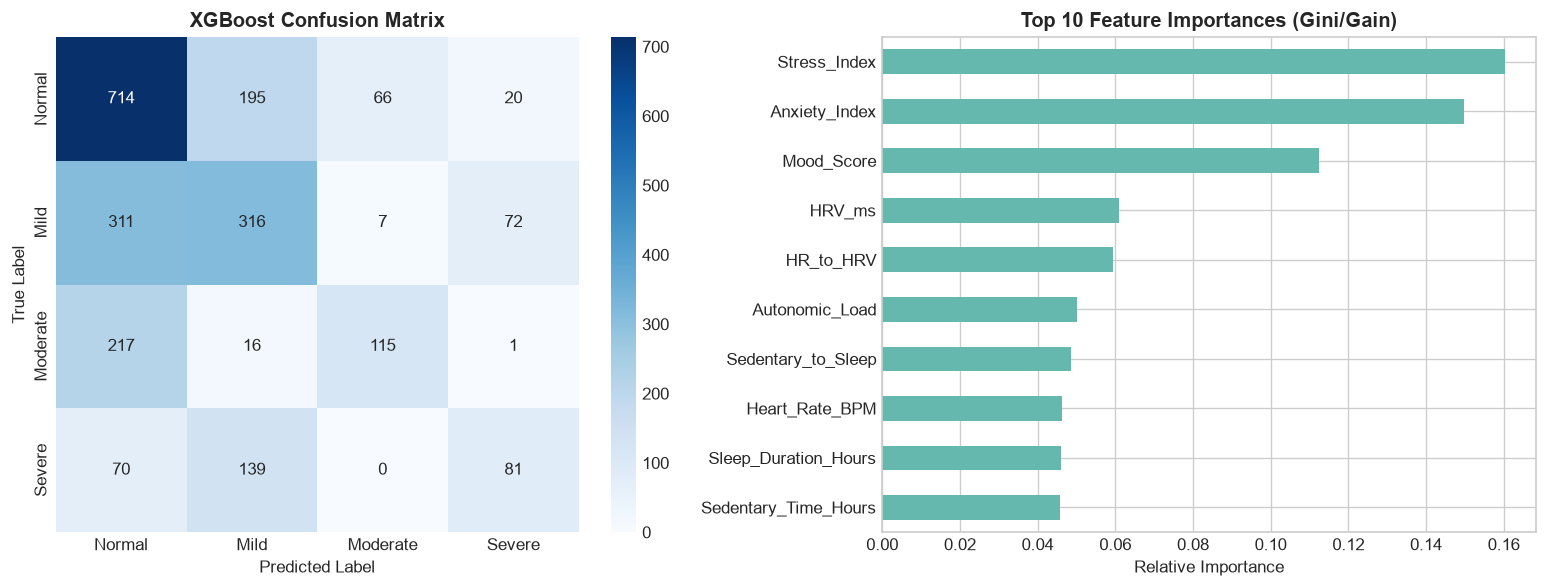


Classification Report (XGBoost):
              precision    recall  f1-score   support

      Normal       0.54      0.72      0.62       995
        Mild       0.47      0.45      0.46       706
    Moderate       0.61      0.33      0.43       349
      Severe       0.47      0.28      0.35       290

    accuracy                           0.52      2340
   macro avg       0.52      0.44      0.46      2340
weighted avg       0.52      0.52      0.51      2340



In [7]:
xgb = models['XGBoost']
y_pred_xgb = xgb.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=order, yticklabels=order, ax=axes[0])
axes[0].set_title('XGBoost Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Top feature importances
importances = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances.tail(10).plot(kind='barh', color='#64b8ad', ax=axes[1])
axes[1].set_title('Top 10 Feature Importances (Gini/Gain)', fontweight='bold')
axes[1].set_xlabel('Relative Importance')

plt.tight_layout()
plt.show()

print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=order))

## 8. Key Takeaways & Thesis Defense Discussion
1. **Physiological Variance Alone:** While wearable biomarkers achieve ~59% test accuracy on 4 complex clinical classes (well above the 25% random guess threshold), autonomic signals are prone to overlap between mild and moderate stress.
2. **Multimodal Motivation:** This provides empirical motivation for integrating a complementary **Linguistic NLP branch (Reddit dataset)** via Decision Late-Fusion (documented in Notebook 03).